# Part B - Feature Preprocessing from Alternative 1

**Input pipeline:** `alternative_1_plane_fitting`  
**Target image:** `Helicene_Ag(111)008.sxm`

This notebook converts the persisted P1 candidate regions into one
unlabelled, model-ready feature row per candidate. It deliberately
stops before annotation matching, train/test splitting, model-specific
scaling, hyperparameter tuning, and model training.

Processing boundary:

```text
P1 object table + label image + corrected height + pixel scale
-> validate object alignment
-> physical size features
-> rotation-stable shape descriptors
-> masked STM-height statistics
-> feature quality checks and visualisation
-> unlabelled feature-table export
```

**No candidate is rotated, aligned, reflected, or augmented.**
Axis-aligned bounding boxes are retained only as metadata for locating
and cropping candidates. Bounding-box height, width, aspect ratio, and
extent are not model features.

## 1. Imports and fixed feature configuration

The feature definitions are fixed before inspecting molecular classes.
Hu values are represented by their log absolute magnitudes so that a
reflection-dependent sign cannot encode the handedness that this
project has chosen to ignore. `mahotas` returns absolute Zernike moments,
which provide a rotation-stable shape fingerprint without rotating the
binary object mask.

In [1]:
import logging
import os
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-codex")
)

import mahotas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from skimage.measure import regionprops

%matplotlib inline

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams["figure.dpi"] = 120

PREPROCESSING_METHOD = "alternative_1_plane_fitting"
ZERNIKE_DEGREE = 8
HU_EPSILON = 1e-30

FORBIDDEN_MODEL_FEATURES = {
    "object_id",
    "centroid_row",
    "centroid_col",
    "min_row",
    "min_col",
    "max_row",
    "max_col",
    "bbox_height",
    "bbox_width",
    "aspect_ratio",
    "extent",
    "quality_flag",
    "class_label",
}

print("Feature preprocessing configuration")
print(f"  P1 method: {PREPROCESSING_METHOD}")
print(f"  Zernike maximum degree: {ZERNIKE_DEGREE}")
print("  Rotation, reflection, alignment, augmentation: disabled")
print("  Model training: disabled")

Feature preprocessing configuration
  P1 method: alternative_1_plane_fitting
  Zernike maximum degree: 8
  Rotation, reflection, alignment, augmentation: disabled
  Model training: disabled


## 2. Locate and load persisted P1 outputs

Four P1 artifacts are loaded:

- `object_index.csv` supplies candidate IDs and location metadata;
- `label_image.npy` defines the exact pixels belonging to each object;
- `corrected_height.npy` supplies the plane-corrected, filtered STM
  height values;
- `processing_summary.csv` supplies the physical pixel scale and
  provenance.

Rendered PNG files are not used as numerical training inputs.

In [2]:
P1_OUTPUT_SUFFIX = Path(
    "project/P1/outputs/alternative_1_plane_fitting"
)


def locate_counting_molecules_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        p1_dir = candidate / P1_OUTPUT_SUFFIX
        required = [
            p1_dir / "object_index.csv",
            p1_dir / "label_image.npy",
            p1_dir / "corrected_height.npy",
            p1_dir / "processing_summary.csv",
        ]
        if all(path.is_file() for path in required):
            return candidate
    raise FileNotFoundError(
        f"Could not locate all P1 outputs below {P1_OUTPUT_SUFFIX}."
    )


PROJECT_ROOT = locate_counting_molecules_root()
P1_OUTPUT_DIR = PROJECT_ROOT / P1_OUTPUT_SUFFIX
OUTPUT_DIR = (
    PROJECT_ROOT / "project" / "P2" / "outputs" /
    "alternative_1_features"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

object_index = pd.read_csv(P1_OUTPUT_DIR / "object_index.csv")
label_image = np.load(P1_OUTPUT_DIR / "label_image.npy")
corrected_height = np.load(P1_OUTPUT_DIR / "corrected_height.npy")
p1_summary = pd.read_csv(P1_OUTPUT_DIR / "processing_summary.csv")


def summary_value(parameter):
    values = p1_summary.loc[
        p1_summary["parameter"] == parameter, "value"
    ]
    if len(values) != 1:
        raise ValueError(f"Expected one summary value for {parameter}.")
    return values.iloc[0]


source_path = Path(str(summary_value("input_file")))
source_image = source_path.name
pixel_scale_x_m = float(summary_value("pixel_scale_x"))
pixel_scale_y_m = float(summary_value("pixel_scale_y"))
linear_scale_nm = np.sqrt(pixel_scale_x_m * pixel_scale_y_m) * 1e9
pixel_area_nm2 = pixel_scale_x_m * pixel_scale_y_m * 1e18

print(f"Project root: {PROJECT_ROOT}")
print(f"P1 output directory: {P1_OUTPUT_DIR}")
print(f"Source image: {source_image}")
print(f"Height shape: {corrected_height.shape}")
print(f"Label range: {label_image.min()} to {label_image.max()}")
print(f"P1 object-table rows: {len(object_index)}")
print(
    "Pixel scale: "
    f"{pixel_scale_x_m * 1e9:.6f} x "
    f"{pixel_scale_y_m * 1e9:.6f} nm/pixel"
)

Project root: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules
P1 output directory: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P1/outputs/alternative_1_plane_fitting
Source image: Helicene_Ag(111)008.sxm
Height shape: (1024, 1024)
Label range: 0 to 248
P1 object-table rows: 248
Pixel scale: 0.078125 x 0.078125 nm/pixel


## 3. Validate object alignment before feature construction

The label image, corrected height matrix, and P1 object index must refer
to exactly the same candidates. Positive labels must be consecutive and
must match `object_id`. P1 area and perimeter are also checked against
fresh `regionprops` measurements so that stale or mismatched files fail
before producing a classification table.

In [3]:
required_object_columns = {
    "object_id",
    "area",
    "perimeter",
    "centroid_row",
    "centroid_col",
    "min_row",
    "min_col",
    "max_row",
    "max_col",
    "quality_flag",
}
missing_columns = required_object_columns.difference(object_index.columns)
assert not missing_columns, f"Missing P1 columns: {sorted(missing_columns)}"

assert corrected_height.ndim == 2
assert corrected_height.shape == label_image.shape
assert np.isfinite(corrected_height).all()
assert np.issubdtype(label_image.dtype, np.integer)
assert label_image.min() == 0

positive_labels = np.unique(label_image[label_image > 0])
expected_labels = np.arange(1, int(label_image.max()) + 1)
assert np.array_equal(positive_labels, expected_labels)
assert np.array_equal(
    object_index["object_id"].to_numpy(dtype=int), expected_labels
)

regions = regionprops(label_image, intensity_image=corrected_height)
assert len(regions) == len(object_index) == int(label_image.max())

measured_area = np.array([region.area for region in regions], dtype=float)
measured_perimeter = np.array(
    [region.perimeter for region in regions], dtype=float
)
assert np.allclose(measured_area, object_index["area"].to_numpy())
assert np.allclose(
    measured_perimeter,
    object_index["perimeter"].to_numpy(),
    rtol=1e-10,
    atol=1e-10,
)

print("P1 alignment checks passed.")
print(f"Aligned candidate regions: {len(regions)}")
print("Area and perimeter agree with the persisted P1 object table.")

P1 alignment checks passed.
Aligned candidate regions: 248
Area and perimeter agree with the persisted P1 object table.


## 4. Define rotation-stable shape and height descriptors

Physical size is obtained from P1's pixel scale. Circularity is

$$C=\frac{4\pi A}{P^2}.$$

Major and minor axis lengths come from the eigenvalues of the region's
second central-moment matrix, not from an axis-aligned bounding box.
Their values and ratio remain stable when the same mask is rotated.

Hu descriptors are exported as log absolute magnitudes. Zernike
descriptors are calculated from each original binary mask around its
mathematical centre of mass. This centre is part of the moment
calculation; the input mask itself is never rotated or rewritten.

In [4]:
def hu_log_absolute(values, epsilon=HU_EPSILON):
    values = np.asarray(values, dtype=float)
    return -np.log10(np.abs(values) + epsilon)


def zernike_magnitudes(local_mask, degree=ZERNIKE_DEGREE):
    local_mask = np.asarray(local_mask, dtype=np.uint8)
    rows, cols = np.nonzero(local_mask)
    if len(rows) == 0:
        raise ValueError("Cannot compute Zernike moments for an empty mask.")
    centre = (float(rows.mean()), float(cols.mean()))
    distances = np.hypot(rows - centre[0], cols - centre[1])
    radius = max(1, int(np.ceil(distances.max())) + 1)
    return np.asarray(
        mahotas.features.zernike_moments(
            local_mask,
            radius=radius,
            degree=degree,
            cm=centre,
        ),
        dtype=float,
    )


def height_statistics(values_m):
    values_pm = np.asarray(values_m, dtype=float) * 1e12
    p10, p90 = np.percentile(values_pm, [10, 90])
    return {
        "height_mean_pm": float(values_pm.mean()),
        "height_median_pm": float(np.median(values_pm)),
        "height_min_pm": float(values_pm.min()),
        "height_max_pm": float(values_pm.max()),
        "height_std_pm": float(values_pm.std(ddof=0)),
        "height_p10_pm": float(p10),
        "height_p90_pm": float(p90),
        "height_range_pm": float(values_pm.max() - values_pm.min()),
        "height_iqr80_pm": float(p90 - p10),
    }


reference_zernike = zernike_magnitudes(regions[0].image)
ZERNIKE_COLUMNS = [
    f"zernike_magnitude_{index:02d}"
    for index in range(len(reference_zernike))
]
HU_COLUMNS = [f"hu_logabs_{index}" for index in range(1, 8)]

print(f"Hu descriptors per candidate: {len(HU_COLUMNS)}")
print(f"Zernike descriptors per candidate: {len(ZERNIKE_COLUMNS)}")
print("No candidate mask has been rotated or reflected.")

Hu descriptors per candidate: 7
Zernike descriptors per candidate: 25
No candidate mask has been rotated or reflected.


## 5. Construct one feature row per P1 candidate

Bounding-box coordinates and centroids are copied only so that future
annotations can be matched and local candidates can be inspected.
Bounding-box dimensions are intentionally omitted. Pixel area and
perimeter are retained as metadata, while their physical-unit versions
become model features.

In [5]:
p1_by_id = object_index.set_index("object_id", verify_integrity=True)
feature_rows = []

for region in regions:
    object_id = int(region.label)
    p1_row = p1_by_id.loc[object_id]
    object_heights = corrected_height[region.slice][region.image]

    area_px = float(region.area)
    perimeter_px = float(region.perimeter)
    major_px = float(region.axis_major_length)
    minor_px = float(region.axis_minor_length)

    circularity = (
        4.0 * np.pi * area_px / perimeter_px**2
        if perimeter_px > 0 else np.nan
    )
    major_minor_ratio = (
        major_px / minor_px if minor_px > 0 else np.nan
    )

    hu_values = hu_log_absolute(region.moments_hu)
    zernike_values = zernike_magnitudes(region.image)
    assert len(zernike_values) == len(ZERNIKE_COLUMNS)

    row = {
        "source_image": source_image,
        "preprocessing_method": PREPROCESSING_METHOD,
        "object_id": object_id,
        "quality_flag": p1_row["quality_flag"],
        "centroid_row": float(region.centroid[0]),
        "centroid_col": float(region.centroid[1]),
        "min_row": int(region.bbox[0]),
        "min_col": int(region.bbox[1]),
        "max_row": int(region.bbox[2]),
        "max_col": int(region.bbox[3]),
        "area_px": area_px,
        "perimeter_px": perimeter_px,
        "area_nm2": area_px * pixel_area_nm2,
        "perimeter_nm": perimeter_px * linear_scale_nm,
        "equivalent_diameter_nm": (
            float(region.equivalent_diameter_area) * linear_scale_nm
        ),
        "major_axis_length_nm": major_px * linear_scale_nm,
        "minor_axis_length_nm": minor_px * linear_scale_nm,
        "major_minor_ratio": major_minor_ratio,
        "circularity": circularity,
        "solidity": float(region.solidity),
        "eccentricity": float(region.eccentricity),
    }
    row.update(height_statistics(object_heights))
    row.update(dict(zip(HU_COLUMNS, hu_values)))
    row.update(dict(zip(ZERNIKE_COLUMNS, zernike_values)))
    feature_rows.append(row)

feature_table = pd.DataFrame(feature_rows).sort_values(
    "object_id"
).reset_index(drop=True)
feature_table["class_label"] = pd.Series(
    pd.NA, index=feature_table.index, dtype="string"
)

print(f"Constructed feature rows: {len(feature_table)}")
print(f"Constructed columns before constant removal: {len(feature_table.columns)}")
display(feature_table.head(8))

Constructed feature rows: 248
Constructed columns before constant removal: 63


,source_image,preprocessing_method,object_id,quality_flag,centroid_row,centroid_col,min_row,min_col,max_row,max_col,...,zernike_magnitude_16,zernike_magnitude_17,zernike_magnitude_18,zernike_magnitude_19,zernike_magnitude_20,zernike_magnitude_21,zernike_magnitude_22,zernike_magnitude_23,zernike_magnitude_24,class_label
0,Helicene_Ag(111)008.sxm,alternative_1_plane_fitting,1,candidate_unvalidated,15.742160,651.533101,6,642,25,662,...,0.021328,0.045119,0.022019,0.003136,0.122065,0.006260,0.009950,0.007891,0.002692,<NA>
1,Helicene_Ag(111)008.sxm,alternative_1_plane_fitting,2,candidate_unvalidated,28.387334,369.979381,12,359,46,383,...,0.000157,0.012574,0.017165,0.009770,0.002106,0.065314,0.072508,0.048148,0.006667,<NA>
2,Helicene_Ag(111)008.sxm,alternative_1_plane_fitting,3,candidate_unvalidated,32.727536,304.936232,21,296,45,316,...,0.014292,0.068336,0.020603,0.007320,0.102383,0.017960,0.016550,0.013099,0.010388,<NA>
3,Helicene_Ag(111)008.sxm,alternative_1_plane_fitting,4,candidate_unvalidated,36.013699,409.409437,21,393,52,427,...,0.006817,0.005031,0.006833,0.002563,0.004924,0.076767,0.080722,0.057694,0.016894,<NA>
4,Helicene_Ag(111)008.sxm,alternative_1_plane_fitting,5,candidate_unvalidated,34.436823,454.772563,26,446,45,465,...,0.028026,0.040098,0.017491,0.004380,0.111808,0.019696,0.016476,0.010180,0.003915,<NA>
5,Helicene_Ag(111)008.sxm,alternative_1_plane_fitting,6,candidate_unvalidated,40.240126,562.807267,27,546,55,580,...,0.004614,0.004610,0.005945,0.007743,0.046885,0.031727,0.077999,0.049322,0.018070,<NA>
6,Helicene_Ag(111)008.sxm,alternative_1_plane_fitting,7,candidate_unvalidated,37.520979,808.055944,28,799,47,818,...,0.015287,0.035673,0.016593,0.007211,0.133693,0.005081,0.018796,0.010452,0.003527,<NA>
7,Helicene_Ag(111)008.sxm,alternative_1_plane_fitting,8,candidate_unvalidated,44.803443,30.767575,29,14,61,48,...,0.004623,0.004669,0.004437,0.005223,0.025618,0.040888,0.076611,0.046538,0.007374,<NA>


## 6. Separate model features from metadata

The model-feature list is explicit rather than inferred from every
numeric column. This prevents `object_id`, location, and bounding-box
coordinates from leaking into a classifier. Exact constant descriptors
carry no discriminatory information and are removed from the exported
model-feature set, with their names recorded for transparency.

In [6]:
METADATA_COLUMNS = [
    "source_image",
    "preprocessing_method",
    "object_id",
    "quality_flag",
    "centroid_row",
    "centroid_col",
    "min_row",
    "min_col",
    "max_row",
    "max_col",
    "area_px",
    "perimeter_px",
]

CORE_FEATURE_COLUMNS = [
    "area_nm2",
    "perimeter_nm",
    "equivalent_diameter_nm",
    "major_axis_length_nm",
    "minor_axis_length_nm",
    "major_minor_ratio",
    "circularity",
    "solidity",
    "eccentricity",
    "height_mean_pm",
    "height_median_pm",
    "height_min_pm",
    "height_max_pm",
    "height_std_pm",
    "height_p10_pm",
    "height_p90_pm",
    "height_range_pm",
    "height_iqr80_pm",
]
CANDIDATE_MODEL_FEATURES = (
    CORE_FEATURE_COLUMNS + HU_COLUMNS + ZERNIKE_COLUMNS
)

constant_features = [
    column for column in CANDIDATE_MODEL_FEATURES
    if feature_table[column].nunique(dropna=False) <= 1
]
MODEL_FEATURE_COLUMNS = [
    column for column in CANDIDATE_MODEL_FEATURES
    if column not in constant_features
]

if constant_features:
    feature_table = feature_table.drop(columns=constant_features)

assert not FORBIDDEN_MODEL_FEATURES.intersection(MODEL_FEATURE_COLUMNS)
assert "bbox_height" not in feature_table.columns
assert "bbox_width" not in feature_table.columns
assert "aspect_ratio" not in feature_table.columns
assert "extent" not in feature_table.columns

ordered_columns = (
    METADATA_COLUMNS + MODEL_FEATURE_COLUMNS + ["class_label"]
)
feature_table = feature_table[ordered_columns]

print(f"Metadata columns: {len(METADATA_COLUMNS)}")
print(f"Model feature columns: {len(MODEL_FEATURE_COLUMNS)}")
print(f"Exact constant descriptors removed: {constant_features or 'none'}")

Metadata columns: 12
Model feature columns: 50
Exact constant descriptors removed: none


## 7. Feature quality checks and descriptive summary

These checks establish that every P1 candidate has one finite feature
row and that no accidental label or location feature has entered the
predictor set. They do not test molecular classification accuracy.

In [7]:
model_matrix = feature_table[MODEL_FEATURE_COLUMNS].to_numpy(dtype=float)

assert len(feature_table) == len(regions)
assert np.array_equal(
    feature_table["object_id"].to_numpy(dtype=int), expected_labels
)
assert np.isfinite(model_matrix).all()
assert feature_table["class_label"].isna().all()
assert not feature_table["object_id"].duplicated().any()

feature_summary = feature_table[MODEL_FEATURE_COLUMNS].describe().T
feature_summary["missing_count"] = feature_table[
    MODEL_FEATURE_COLUMNS
].isna().sum()
feature_summary["nonfinite_count"] = [
    int((~np.isfinite(feature_table[column].to_numpy(dtype=float))).sum())
    for column in MODEL_FEATURE_COLUMNS
]
feature_summary["unique_count"] = feature_table[
    MODEL_FEATURE_COLUMNS
].nunique()

print("Feature quality checks passed.")
print(f"Rows: {len(feature_table)}")
print(f"Finite model features: {len(MODEL_FEATURE_COLUMNS)}")
print("Assigned class labels: 0")
display(feature_summary.head(12))

Feature quality checks passed.
Rows: 248
Finite model features: 50
Assigned class labels: 0


,count,mean,std,min,25%,50%,75%,max,missing_count,nonfinite_count,unique_count
area_nm2,248.0,3.805690,1.917100,1.690674,2.105713,3.967285,4.101563,8.630371,0,0,136
perimeter_nm,248.0,7.300222,2.041952,4.663944,5.348926,7.777166,7.937342,12.318847,0,0,115
equivalent_diameter_nm,248.0,2.137189,0.528301,1.467185,1.637399,2.247511,2.285229,3.314895,0,0,136
major_axis_length_nm,248.0,2.502038,0.672487,1.591631,1.774421,2.842609,2.877879,4.675619,0,0,248
minor_axis_length_nm,248.0,1.891714,0.525026,1.344409,1.539577,1.824503,1.869004,3.284325,0,0,248
major_minor_ratio,248.0,1.332613,0.219642,1.003273,1.148832,1.262844,1.550400,1.947389,0,0,248
circularity,248.0,0.863396,0.065604,0.707584,0.816516,0.832795,0.931096,0.990808,0,0,234
solidity,248.0,0.950960,0.011795,0.923483,0.942446,0.948662,0.960066,0.979381,0,0,232
eccentricity,248.0,0.593128,0.193784,0.080711,0.492258,0.610613,0.764187,0.858085,0,0,248
height_mean_pm,248.0,86.937037,6.714818,76.576515,80.538307,88.829810,90.214668,102.415012,0,0,248


## 8. Diagnostic feature visualisations

These plots show the preprocessing result before any class labels or
models are introduced. They help identify skewed distributions,
outliers, redundant descriptors, and candidate groups that may require
later annotation or error analysis.

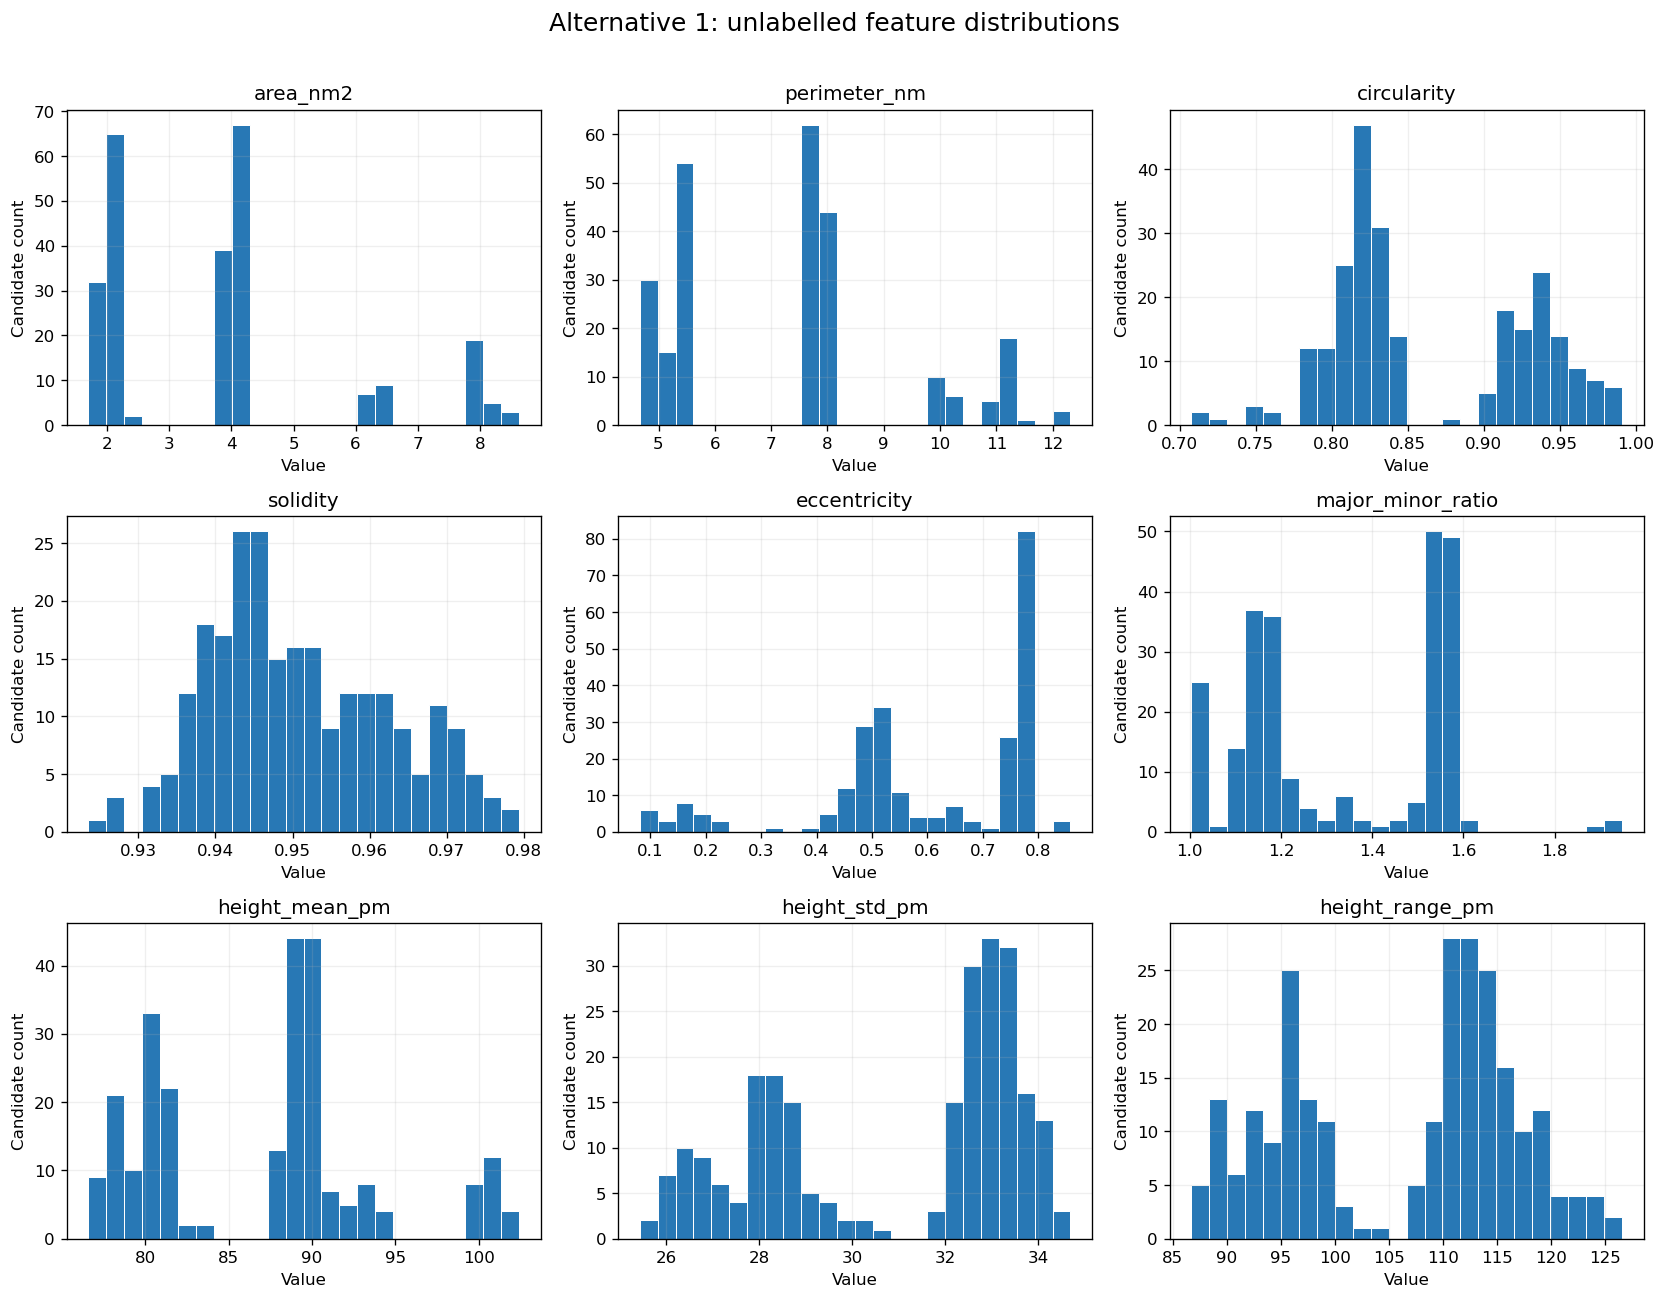

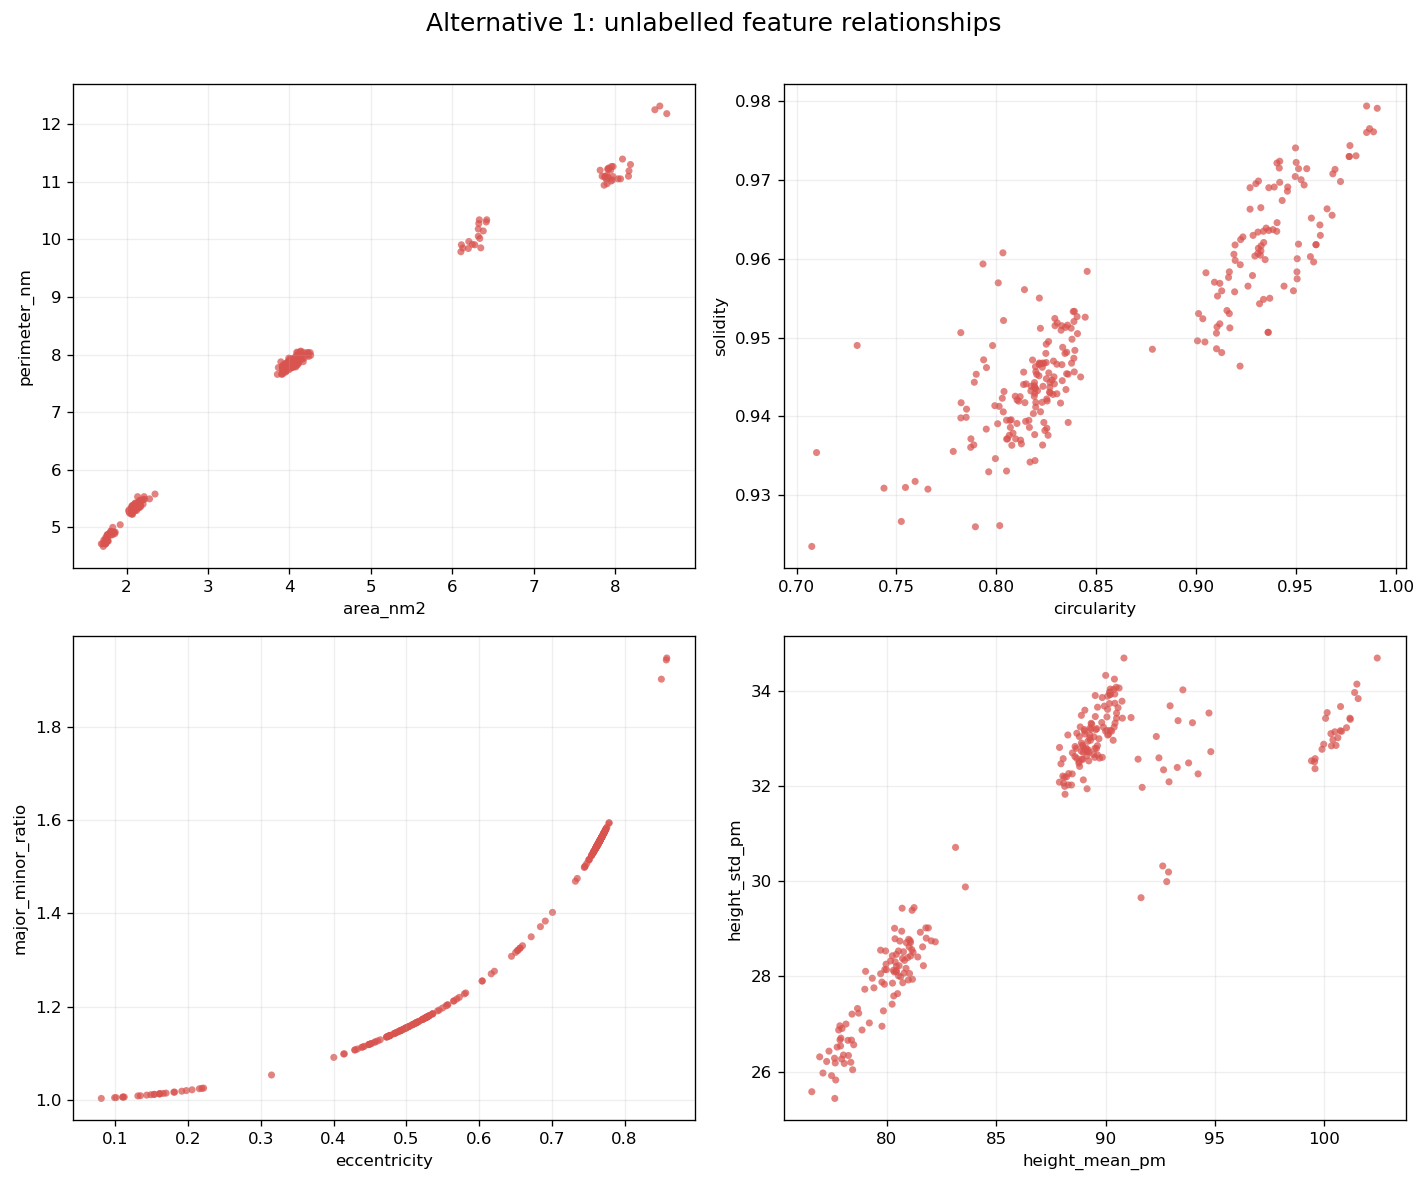

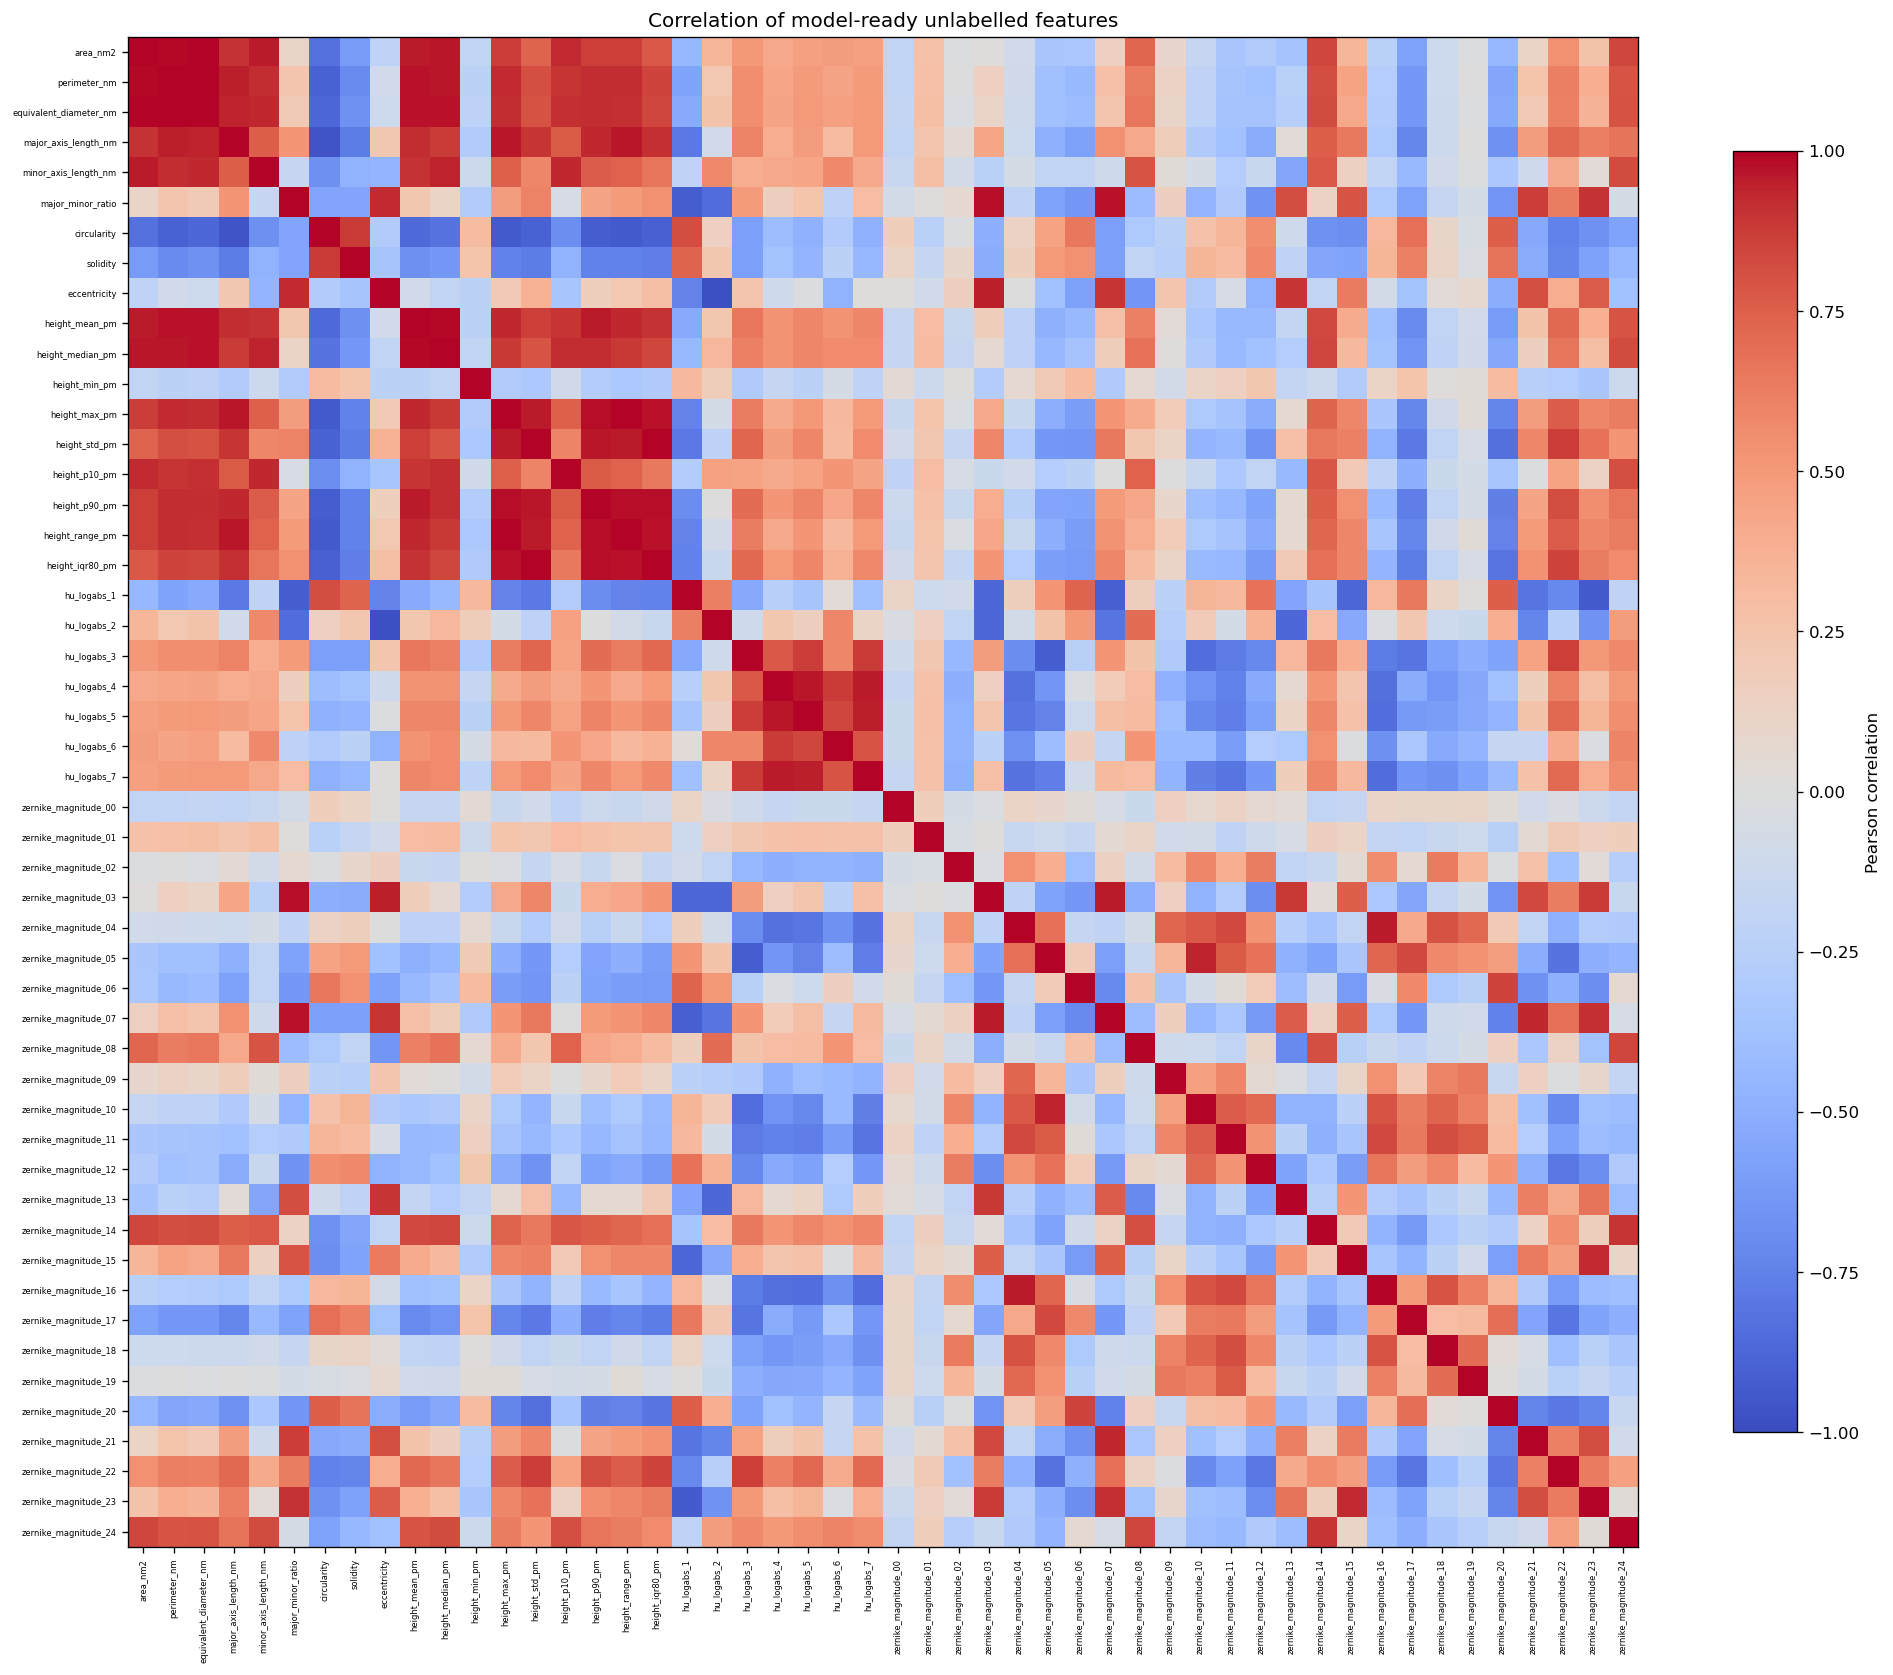

Saved: feature_distributions.png
Saved: feature_relationships.png
Saved: feature_correlation.png


In [8]:
distribution_features = [
    "area_nm2",
    "perimeter_nm",
    "circularity",
    "solidity",
    "eccentricity",
    "major_minor_ratio",
    "height_mean_pm",
    "height_std_pm",
    "height_range_pm",
]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, feature in zip(axes.flat, distribution_features):
    ax.hist(
        feature_table[feature],
        bins=24,
        color="#2878B5",
        edgecolor="white",
        linewidth=0.6,
    )
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Candidate count")
    ax.grid(alpha=0.2)

fig.suptitle(
    "Alternative 1: unlabelled feature distributions",
    fontsize=15,
)
plt.tight_layout(rect=(0, 0, 1, 0.97))
distribution_path = OUTPUT_DIR / "feature_distributions.png"
fig.savefig(distribution_path, dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
relationships = [
    ("area_nm2", "perimeter_nm"),
    ("circularity", "solidity"),
    ("eccentricity", "major_minor_ratio"),
    ("height_mean_pm", "height_std_pm"),
]
for ax, (x_feature, y_feature) in zip(axes.flat, relationships):
    ax.scatter(
        feature_table[x_feature],
        feature_table[y_feature],
        s=18,
        alpha=0.72,
        color="#D9534F",
        edgecolors="none",
    )
    ax.set_xlabel(x_feature)
    ax.set_ylabel(y_feature)
    ax.grid(alpha=0.2)

fig.suptitle(
    "Alternative 1: unlabelled feature relationships",
    fontsize=15,
)
plt.tight_layout(rect=(0, 0, 1, 0.97))
relationships_path = OUTPUT_DIR / "feature_relationships.png"
fig.savefig(relationships_path, dpi=200, bbox_inches="tight")
plt.show()

correlation = feature_table[MODEL_FEATURE_COLUMNS].corr()
fig, ax = plt.subplots(figsize=(17, 15))
image = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
positions = np.arange(len(MODEL_FEATURE_COLUMNS))
ax.set_xticks(positions)
ax.set_yticks(positions)
ax.set_xticklabels(MODEL_FEATURE_COLUMNS, rotation=90, fontsize=5)
ax.set_yticklabels(MODEL_FEATURE_COLUMNS, fontsize=5)
ax.set_title("Correlation of model-ready unlabelled features")
fig.colorbar(image, ax=ax, label="Pearson correlation", shrink=0.75)
plt.tight_layout()
correlation_path = OUTPUT_DIR / "feature_correlation.png"
fig.savefig(correlation_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {distribution_path.name}")
print(f"Saved: {relationships_path.name}")
print(f"Saved: {correlation_path.name}")

## 9. Export the unlabelled classification table and manifest

`classification_features_unlabelled.csv` is the hand-off from P1 to P2.
The empty `class_label` column is intentional. It must later be filled
only after candidates are matched to the independent annotated
reference image.

In [9]:
feature_table_path = OUTPUT_DIR / "classification_features_unlabelled.csv"
manifest_path = OUTPUT_DIR / "feature_manifest.csv"
feature_summary_path = OUTPUT_DIR / "feature_summary.csv"
preprocessing_summary_path = (
    OUTPUT_DIR / "feature_preprocessing_summary.csv"
)

metadata_descriptions = {
    "source_image": "Original SXM filename",
    "preprocessing_method": "P1 method that produced the candidate",
    "object_id": "Pipeline-specific connected-component identifier",
    "quality_flag": "P1 candidate status; not a predictor",
    "centroid_row": "Candidate centroid row for annotation matching",
    "centroid_col": "Candidate centroid column for annotation matching",
    "min_row": "Bounding-box top row for locating the candidate",
    "min_col": "Bounding-box left column for locating the candidate",
    "max_row": "Bounding-box exclusive bottom row",
    "max_col": "Bounding-box exclusive right column",
    "area_px": "Pixel area retained for diagnostics",
    "perimeter_px": "Pixel perimeter retained for diagnostics",
}
feature_units = {
    "area_nm2": "nm^2",
    "perimeter_nm": "nm",
    "equivalent_diameter_nm": "nm",
    "major_axis_length_nm": "nm",
    "minor_axis_length_nm": "nm",
}
for column in MODEL_FEATURE_COLUMNS:
    if column.startswith("height_"):
        feature_units[column] = "pm"
    else:
        feature_units.setdefault(column, "dimensionless")

manifest_rows = []
for column in METADATA_COLUMNS:
    manifest_rows.append(
        {
            "column": column,
            "role": "metadata",
            "unit": "",
            "description": metadata_descriptions[column],
        }
    )
for column in MODEL_FEATURE_COLUMNS:
    manifest_rows.append(
        {
            "column": column,
            "role": "model_feature",
            "unit": feature_units[column],
            "description": (
                "Rotation-stable object descriptor computed without "
                "rotating the candidate"
            ),
        }
    )
manifest_rows.append(
    {
        "column": "class_label",
        "role": "future_target",
        "unit": "",
        "description": "Empty until independent annotation matching",
    }
)
feature_manifest = pd.DataFrame(manifest_rows)

preprocessing_summary = pd.DataFrame(
    [
        ("source_image", source_image),
        ("p1_preprocessing_method", PREPROCESSING_METHOD),
        ("candidate_rows", len(feature_table)),
        ("model_feature_count", len(MODEL_FEATURE_COLUMNS)),
        ("metadata_column_count", len(METADATA_COLUMNS)),
        ("zernike_degree", ZERNIKE_DEGREE),
        ("rotation_applied", False),
        ("reflection_applied", False),
        ("augmentation_applied", False),
        ("class_labels_assigned", 0),
        ("constant_features_removed", ";".join(constant_features)),
        ("all_model_features_finite", True),
    ],
    columns=["check", "value"],
)

feature_table.to_csv(feature_table_path, index=False)
feature_manifest.to_csv(manifest_path, index=False)
feature_summary.to_csv(feature_summary_path, index=True)
preprocessing_summary.to_csv(preprocessing_summary_path, index=False)

print("Exported preprocessing artifacts:")
for path in [
    feature_table_path,
    manifest_path,
    feature_summary_path,
    preprocessing_summary_path,
    distribution_path,
    relationships_path,
    correlation_path,
]:
    print(f"  {path.name}: {path.stat().st_size:,} bytes")

Exported preprocessing artifacts:
  classification_features_unlabelled.csv: 281,363 bytes
  feature_manifest.csv: 6,676 bytes
  feature_summary.csv: 8,546 bytes
  feature_preprocessing_summary.csv: 342 bytes
  feature_distributions.png: 215,703 bytes
  feature_relationships.png: 264,143 bytes
  feature_correlation.png: 316,261 bytes


## 10. Reload and validate the exported hand-off

The final Cell reads the files from disk rather than trusting only the
in-memory variables. Passing these checks demonstrates structural
consistency. It does not establish molecule-detection accuracy,
class-label accuracy, or classifier performance.

In [10]:
reloaded_features = pd.read_csv(feature_table_path)
reloaded_manifest = pd.read_csv(manifest_path)
reloaded_feature_summary = pd.read_csv(feature_summary_path, index_col=0)
reloaded_preprocessing_summary = pd.read_csv(preprocessing_summary_path)

reloaded_model_features = reloaded_manifest.loc[
    reloaded_manifest["role"] == "model_feature", "column"
].tolist()

assert len(reloaded_features) == int(label_image.max()) == len(object_index)
assert np.array_equal(
    reloaded_features["object_id"].to_numpy(dtype=int), expected_labels
)
assert reloaded_model_features == MODEL_FEATURE_COLUMNS
assert not FORBIDDEN_MODEL_FEATURES.intersection(reloaded_model_features)
assert np.isfinite(
    reloaded_features[reloaded_model_features].to_numpy(dtype=float)
).all()
assert reloaded_features["class_label"].isna().all()
assert len(reloaded_feature_summary) == len(MODEL_FEATURE_COLUMNS)
assert len(reloaded_preprocessing_summary) == 12

expected_outputs = [
    feature_table_path,
    manifest_path,
    feature_summary_path,
    preprocessing_summary_path,
    distribution_path,
    relationships_path,
    correlation_path,
]
assert all(path.is_file() and path.stat().st_size > 0 for path in expected_outputs)

print("All feature-preprocessing validation checks passed.")
print(f"Unlabelled candidate rows: {len(reloaded_features)}")
print(f"Model-ready feature columns: {len(reloaded_model_features)}")
print("Rotation/reflection/augmentation applied: no / no / no")
print("Model fitted: no")
print(f"Output directory: {OUTPUT_DIR}")

All feature-preprocessing validation checks passed.
Unlabelled candidate rows: 248
Model-ready feature columns: 50
Rotation/reflection/augmentation applied: no / no / no
Model fitted: no
Output directory: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P2/outputs/alternative_1_features


## End of preprocessing before model training

The next stage is independent annotation matching. Only candidates with
a defensible one-to-one reference match should receive one of the target
classes: Dimer, Trimer, Tetramer, P2, or P3. Scaling and feature
selection for SVM or Logistic Regression must later be fitted inside
cross-validation; Random Forest can use the exported numerical features
without mandatory scaling.

# Part C - Area and Perimeter K-means Clustering (`k = 5`)

## Research question

Can the 248 unlabelled candidates produced by Alternative 1 be separated into five stable geometric groups using only physical area and perimeter?

This is an **unsupervised baseline**. Setting `k = 5` forces the algorithm to return five groups; it does not prove that the groups are P2, P3, Dimer of P1, Trimer of P1, and Tetramer of P1. Chemical names must be assigned later by matching cluster members to the paper's annotated ground truth.

The two clustering coordinates are retained separately:

- `area_nm2`: candidate mask area in square nanometres;
- `perimeter_nm`: candidate mask boundary length in nanometres.

The code does not replace them with a single perimeter/area ratio, because that would collapse the visible two-dimensional grouping into one number.

## 11. Configure and validate the clustering input

**Purpose:** select exactly the two approved features, create a dedicated output directory, and reject missing or non-finite values before fitting a model.

The features are standardised later because K-means uses Euclidean distance. Standardisation prevents the feature with the larger numerical scale from dominating that distance.

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

CLUSTER_FEATURES = ["area_nm2", "perimeter_nm"]
N_CLUSTERS = 5
CLUSTER_RANDOM_STATE = 42
CLUSTER_N_INIT = 100
CLUSTER_OUTPUT_DIR = OUTPUT_DIR / "area_perimeter_kmeans"
CLUSTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

missing_features = sorted(set(CLUSTER_FEATURES) - set(feature_table.columns))
if missing_features:
    raise KeyError(f"Missing clustering features: {missing_features}")

X_cluster = feature_table[CLUSTER_FEATURES].copy()
if X_cluster.isna().any().any():
    raise ValueError("Clustering features contain missing values.")
if not np.isfinite(X_cluster.to_numpy(dtype=float)).all():
    raise ValueError("Clustering features contain non-finite values.")

print(f"Candidates supplied to clustering: {len(X_cluster)}")
print(f"Fixed cluster target: {N_CLUSTERS}")
display(X_cluster.describe().T)

Candidates supplied to clustering: 248
Fixed cluster target: 5


,count,mean,std,min,25%,50%,75%,max
area_nm2,248.0,3.805690,1.917100,1.690674,2.105713,3.967285,4.101563,8.630371
perimeter_nm,248.0,7.300222,2.041952,4.663944,5.348926,7.777166,7.937342,12.318847


## 12. Standardise the two coordinates and fit K-means

For each feature, `StandardScaler` applies

\[
z = \frac{x - \mu}{\sigma}.
\]

K-means then minimises the within-cluster sum of squared distances:

\[
J = \sum_{j=1}^{5}\sum_{x_i\in C_j}\lVert z_i-\mu_j\rVert^2.
\]

`k-means++` supplies well-spread starting centres, and `n_init=100` repeats the optimisation to reduce dependence on a poor initialisation. Raw K-means labels have no order, so the groups are renamed `C1` to `C5` by increasing centre area. This makes the exported labels stable and interpretable across reruns.

In [12]:
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    init="k-means++",
    n_init=CLUSTER_N_INIT,
    random_state=CLUSTER_RANDOM_STATE,
)
raw_cluster_labels = kmeans.fit_predict(X_cluster_scaled)
raw_centres_original = cluster_scaler.inverse_transform(
    kmeans.cluster_centers_
)

# Rename the arbitrary raw labels by increasing physical area.
raw_order = np.argsort(raw_centres_original[:, 0])
raw_to_stable = {
    int(raw_label): int(stable_label)
    for stable_label, raw_label in enumerate(raw_order, start=1)
}
stable_cluster_labels = np.array(
    [raw_to_stable[int(label)] for label in raw_cluster_labels],
    dtype=int,
)

clustered_table = feature_table.copy()
clustered_table["cluster_id"] = stable_cluster_labels
clustered_table["cluster_label"] = [
    f"C{cluster_id}" for cluster_id in stable_cluster_labels
]
clustered_table["distance_to_cluster_centre"] = np.linalg.norm(
    X_cluster_scaled - kmeans.cluster_centers_[raw_cluster_labels],
    axis=1,
)

stable_centres = pd.DataFrame(
    [
        {
            "cluster_id": stable_label,
            "cluster_label": f"C{stable_label}",
            "centre_area_nm2": raw_centres_original[raw_label, 0],
            "centre_perimeter_nm": raw_centres_original[raw_label, 1],
        }
        for raw_label, stable_label in raw_to_stable.items()
    ]
).sort_values("cluster_id").reset_index(drop=True)

cluster_counts = (
    clustered_table.groupby(["cluster_id", "cluster_label"])
    .size()
    .rename("candidate_count")
    .reset_index()
)
cluster_summary = stable_centres.merge(
    cluster_counts,
    on=["cluster_id", "cluster_label"],
    validate="one_to_one",
)

assert set(clustered_table["cluster_id"]) == set(range(1, 6))
assert cluster_summary["candidate_count"].sum() == len(feature_table)

display(cluster_summary)

,cluster_id,cluster_label,centre_area_nm2,centre_perimeter_nm,candidate_count
0,1,C1,1.779366,4.823300,32
1,2,C2,2.122110,5.361627,67
2,3,C3,4.033618,7.850438,106
3,4,C4,6.277466,10.043064,16
4,5,C5,8.025445,11.260920,27


## 13. Quantify separation and repeatability

These are **internal clustering metrics** because no class labels are used:

- **Silhouette score:** ranges from `-1` to `1`; larger is better separated.
- **Calinski-Harabasz score:** compares between-group and within-group dispersion; useful when comparing candidate pipelines, with larger values preferred.
- **Davies-Bouldin index:** compares within-group spread with separation between groups; smaller is preferred.
- **Seed stability ARI:** repeats K-means with different random seeds and compares assignments using Adjusted Rand Index. A value of `1` means identical partitions, allowing for arbitrary label numbers.

Good internal scores show that the geometry forms stable groups. They do not show that the groups have the correct chemical names.

In [13]:
sample_silhouette = silhouette_samples(
    X_cluster_scaled,
    stable_cluster_labels,
)
clustered_table["silhouette_value"] = sample_silhouette

seed_partitions = [
    KMeans(
        n_clusters=N_CLUSTERS,
        init="k-means++",
        n_init=50,
        random_state=seed,
    ).fit_predict(X_cluster_scaled)
    for seed in range(10)
]
seed_ari_values = [
    adjusted_rand_score(seed_partitions[0], labels)
    for labels in seed_partitions[1:]
]

cluster_metrics = pd.DataFrame(
    [
        {
            "metric": "silhouette_score",
            "value": silhouette_score(
                X_cluster_scaled, stable_cluster_labels
            ),
            "preferred_direction": "higher; maximum 1",
        },
        {
            "metric": "calinski_harabasz_score",
            "value": calinski_harabasz_score(
                X_cluster_scaled, stable_cluster_labels
            ),
            "preferred_direction": "higher when comparing pipelines",
        },
        {
            "metric": "davies_bouldin_score",
            "value": davies_bouldin_score(
                X_cluster_scaled, stable_cluster_labels
            ),
            "preferred_direction": "lower; minimum 0",
        },
        {
            "metric": "seed_stability_ari_min",
            "value": min(seed_ari_values),
            "preferred_direction": "higher; maximum 1",
        },
        {
            "metric": "seed_stability_ari_mean",
            "value": float(np.mean(seed_ari_values)),
            "preferred_direction": "higher; maximum 1",
        },
        {
            "metric": "kmeans_inertia",
            "value": float(kmeans.inertia_),
            "preferred_direction": "comparison only; lower",
        },
    ]
)

display(cluster_metrics)

,metric,value,preferred_direction
0,silhouette_score,0.877585,higher; maximum 1
1,calinski_harabasz_score,14590.854729,higher when comparing pipelines
2,davies_bouldin_score,0.214574,lower; minimum 0
3,seed_stability_ari_min,1.000000,higher; maximum 1
4,seed_stability_ari_mean,1.000000,higher; maximum 1
5,kmeans_inertia,2.056567,comparison only; lower


## 14. Plot the five groups in physical units

Each coloured point is one P1 candidate. The black `X` markers are K-means centres after converting them back from standardised coordinates to `nm^2` and `nm`. The legend reports the number of candidates in each group.

This is the main visual result for the area-perimeter baseline.

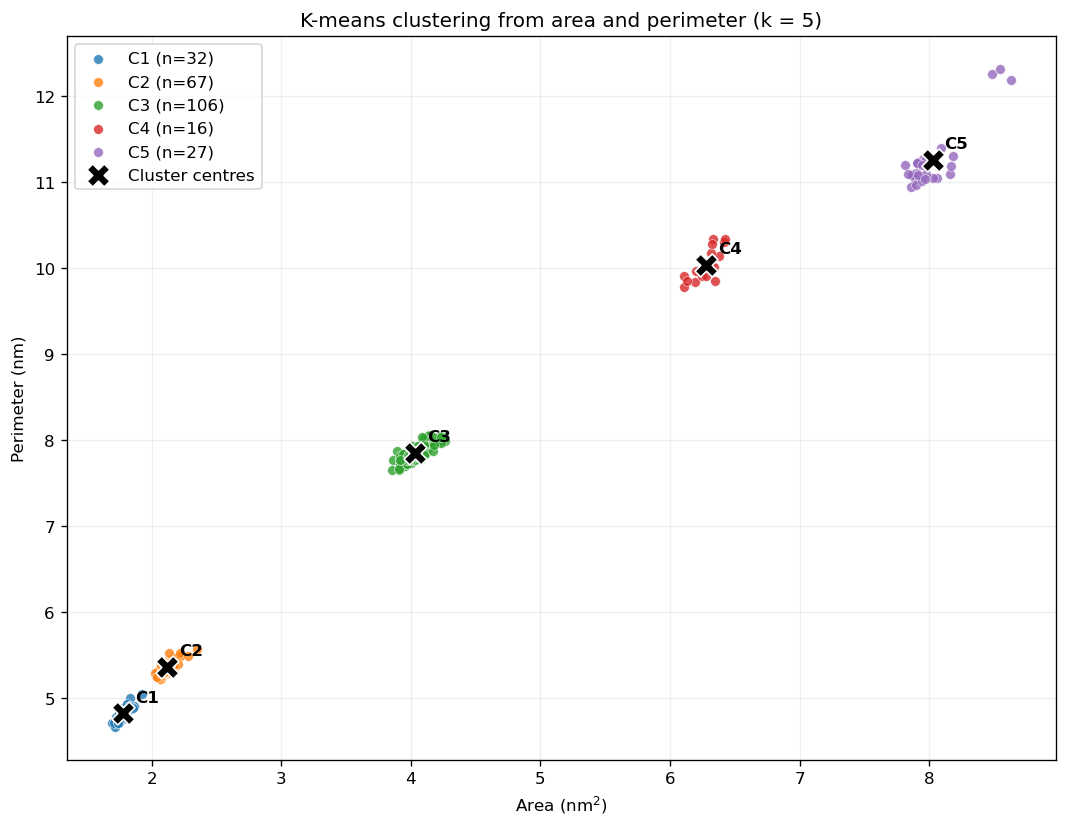

In [14]:
CLUSTER_COLOURS = list(plt.colormaps["tab10"].colors[:N_CLUSTERS])

fig, ax = plt.subplots(figsize=(9, 7))
for cluster_id, colour in zip(range(1, 6), CLUSTER_COLOURS):
    group = clustered_table.loc[
        clustered_table["cluster_id"] == cluster_id
    ]
    ax.scatter(
        group["area_nm2"],
        group["perimeter_nm"],
        s=34,
        alpha=0.80,
        color=colour,
        edgecolors="white",
        linewidths=0.35,
        label=f"C{cluster_id} (n={len(group)})",
    )

ax.scatter(
    stable_centres["centre_area_nm2"],
    stable_centres["centre_perimeter_nm"],
    marker="X",
    s=190,
    color="black",
    edgecolors="white",
    linewidths=1.0,
    label="Cluster centres",
    zorder=5,
)
for centre in stable_centres.itertuples(index=False):
    ax.annotate(
        centre.cluster_label,
        (centre.centre_area_nm2, centre.centre_perimeter_nm),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

ax.set_xlabel("Area (nm$^2$)")
ax.set_ylabel("Perimeter (nm)")
ax.set_title("K-means clustering from area and perimeter (k = 5)")
ax.grid(alpha=0.20)
ax.legend(frameon=True)
plt.tight_layout()

cluster_scatter_path = (
    CLUSTER_OUTPUT_DIR / "area_perimeter_kmeans_scatter.png"
)
fig.savefig(cluster_scatter_path, dpi=220, bbox_inches="tight")
plt.show()

## 15. Inspect point-level cluster confidence with a silhouette plot

Each horizontal segment is one candidate's silhouette value. Values close to `1` indicate that a candidate is much closer to its assigned cluster than to neighbouring clusters. Values near `0` identify boundary cases. Negative values would indicate candidates that may fit another cluster better.

The dashed vertical line is the overall silhouette score.

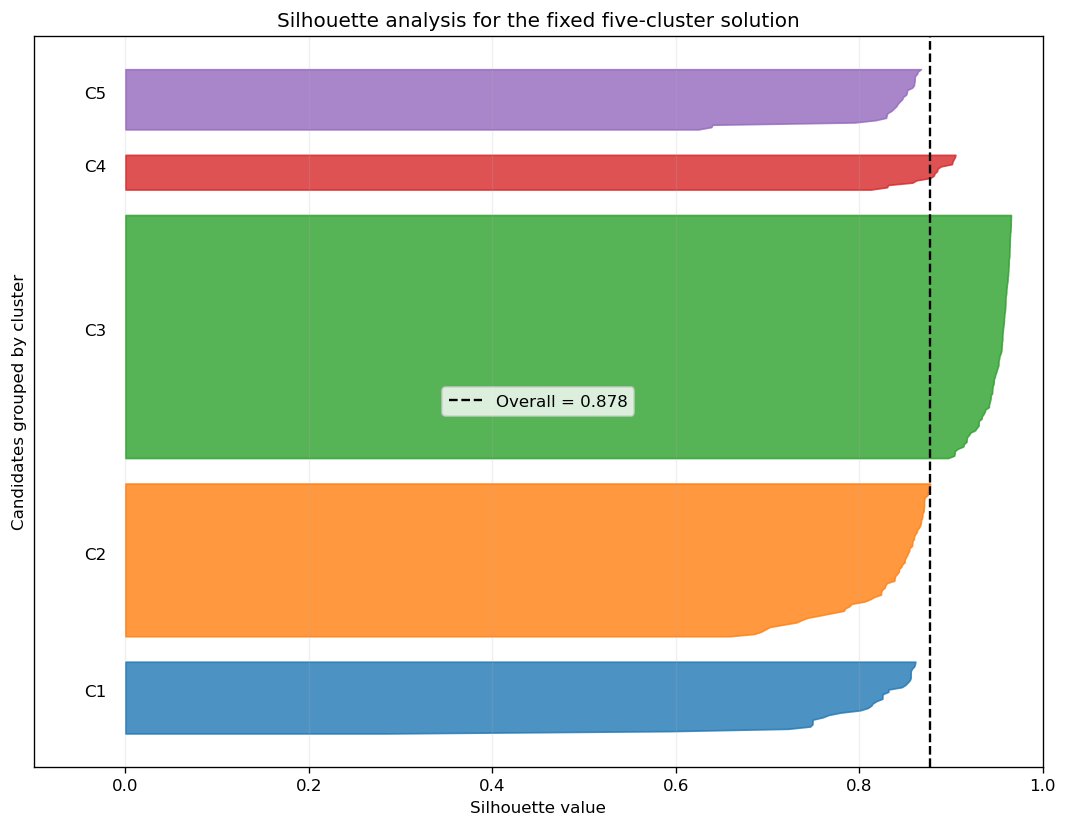

In [15]:
overall_silhouette = float(
    cluster_metrics.loc[
        cluster_metrics["metric"] == "silhouette_score", "value"
    ].iloc[0]
)

fig, ax = plt.subplots(figsize=(9, 7))
y_lower = 10
for cluster_id, colour in zip(range(1, 6), CLUSTER_COLOURS):
    values = np.sort(
        clustered_table.loc[
            clustered_table["cluster_id"] == cluster_id,
            "silhouette_value",
        ].to_numpy()
    )
    y_upper = y_lower + len(values)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        values,
        facecolor=colour,
        edgecolor=colour,
        alpha=0.80,
    )
    ax.text(-0.045, y_lower + len(values) / 2, f"C{cluster_id}")
    y_lower = y_upper + 10

ax.axvline(
    overall_silhouette,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label=f"Overall = {overall_silhouette:.3f}",
)
ax.set_xlim(-0.10, 1.00)
ax.set_xlabel("Silhouette value")
ax.set_ylabel("Candidates grouped by cluster")
ax.set_yticks([])
ax.set_title("Silhouette analysis for the fixed five-cluster solution")
ax.grid(axis="x", alpha=0.20)
ax.legend()
plt.tight_layout()

silhouette_path = CLUSTER_OUTPUT_DIR / "area_perimeter_silhouette.png"
fig.savefig(silhouette_path, dpi=220, bbox_inches="tight")
plt.show()

## 16. Map cluster assignments back to the STM field of view

The original candidate IDs are preserved, so the cluster table can be joined directly to `label_image.npy`. The corrected STM height is shown in greyscale, while semi-transparent colours identify C1-C5.

This spatial check is important because a numerically clean group can still contain visibly incorrect segmentation, merged neighbours, or unexpected artefacts.

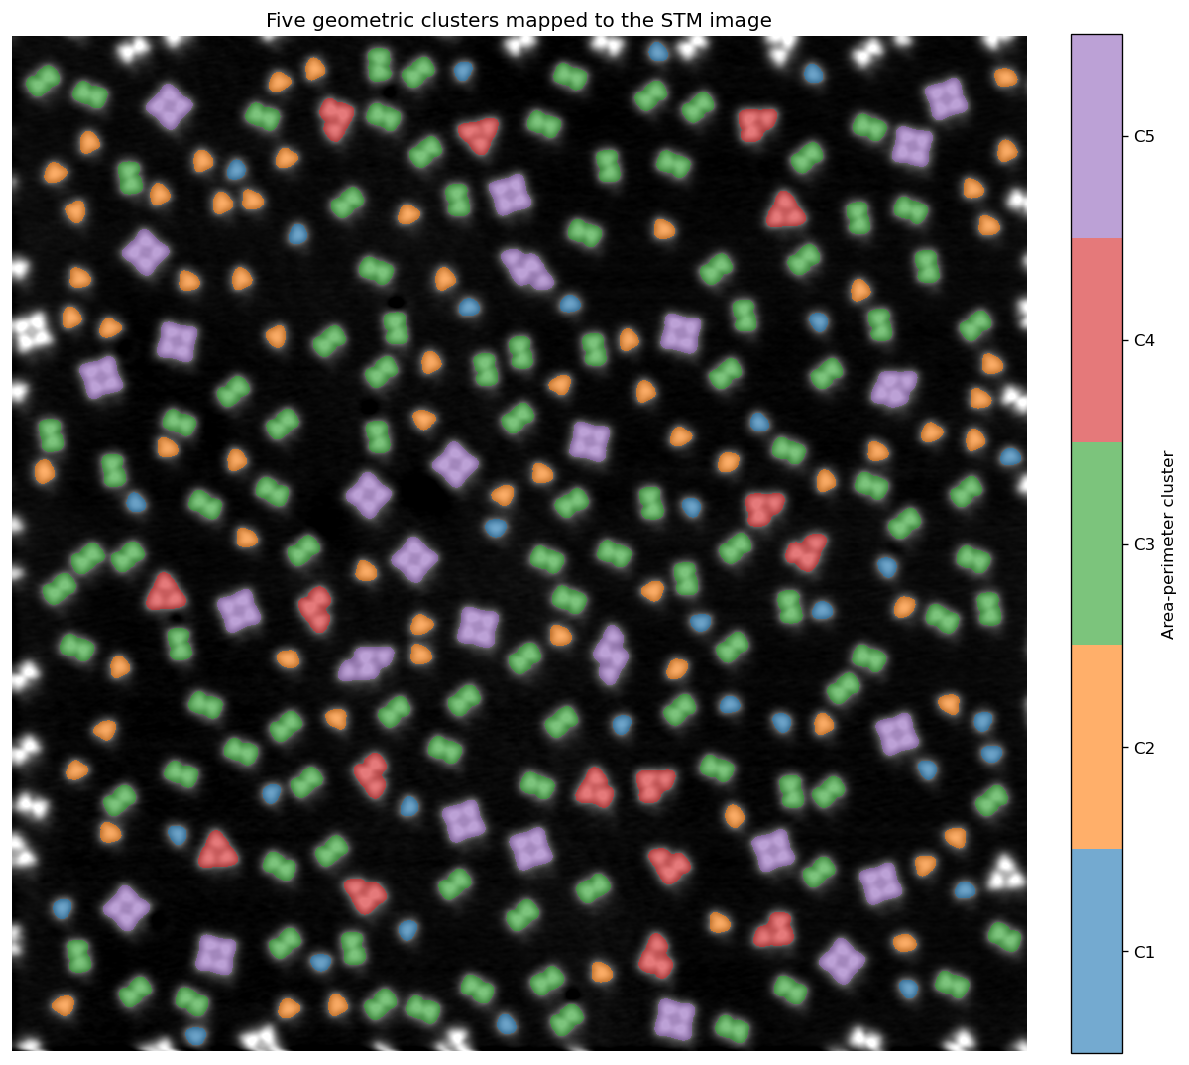

In [16]:
cluster_lookup = np.zeros(int(label_image.max()) + 1, dtype=np.int16)
for row in clustered_table[["object_id", "cluster_id"]].itertuples(
    index=False
):
    cluster_lookup[int(row.object_id)] = int(row.cluster_id)

cluster_label_image = cluster_lookup[label_image]
assert np.array_equal(
    np.unique(cluster_label_image), np.arange(0, N_CLUSTERS + 1)
)

cluster_cmap = ListedColormap(CLUSTER_COLOURS)
overlay = np.ma.masked_where(cluster_label_image == 0, cluster_label_image)
height_vmin, height_vmax = np.percentile(corrected_height, [1, 99])

fig, ax = plt.subplots(figsize=(10, 9))
ax.imshow(
    corrected_height,
    cmap="gray",
    vmin=height_vmin,
    vmax=height_vmax,
    interpolation="nearest",
)
overlay_artist = ax.imshow(
    overlay,
    cmap=cluster_cmap,
    vmin=0.5,
    vmax=5.5,
    alpha=0.62,
    interpolation="nearest",
)
colourbar = fig.colorbar(
    overlay_artist,
    ax=ax,
    ticks=np.arange(1, 6),
    fraction=0.046,
    pad=0.04,
)
colourbar.ax.set_yticklabels([f"C{i}" for i in range(1, 6)])
colourbar.set_label("Area-perimeter cluster")
ax.set_title("Five geometric clusters mapped to the STM image")
ax.set_axis_off()
plt.tight_layout()

cluster_overlay_path = (
    CLUSTER_OUTPUT_DIR / "area_perimeter_cluster_overlay.png"
)
fig.savefig(cluster_overlay_path, dpi=220, bbox_inches="tight")
plt.show()

## 17. Display typical candidates from each cluster

For every cluster, the eight candidates closest to its K-means centre are shown. These are geometric prototypes, not chemically verified examples. A shared height scale is used across all crops so that brightness remains comparable.

This montage is the main qualitative check before attempting to attach molecular class names to C1-C5.

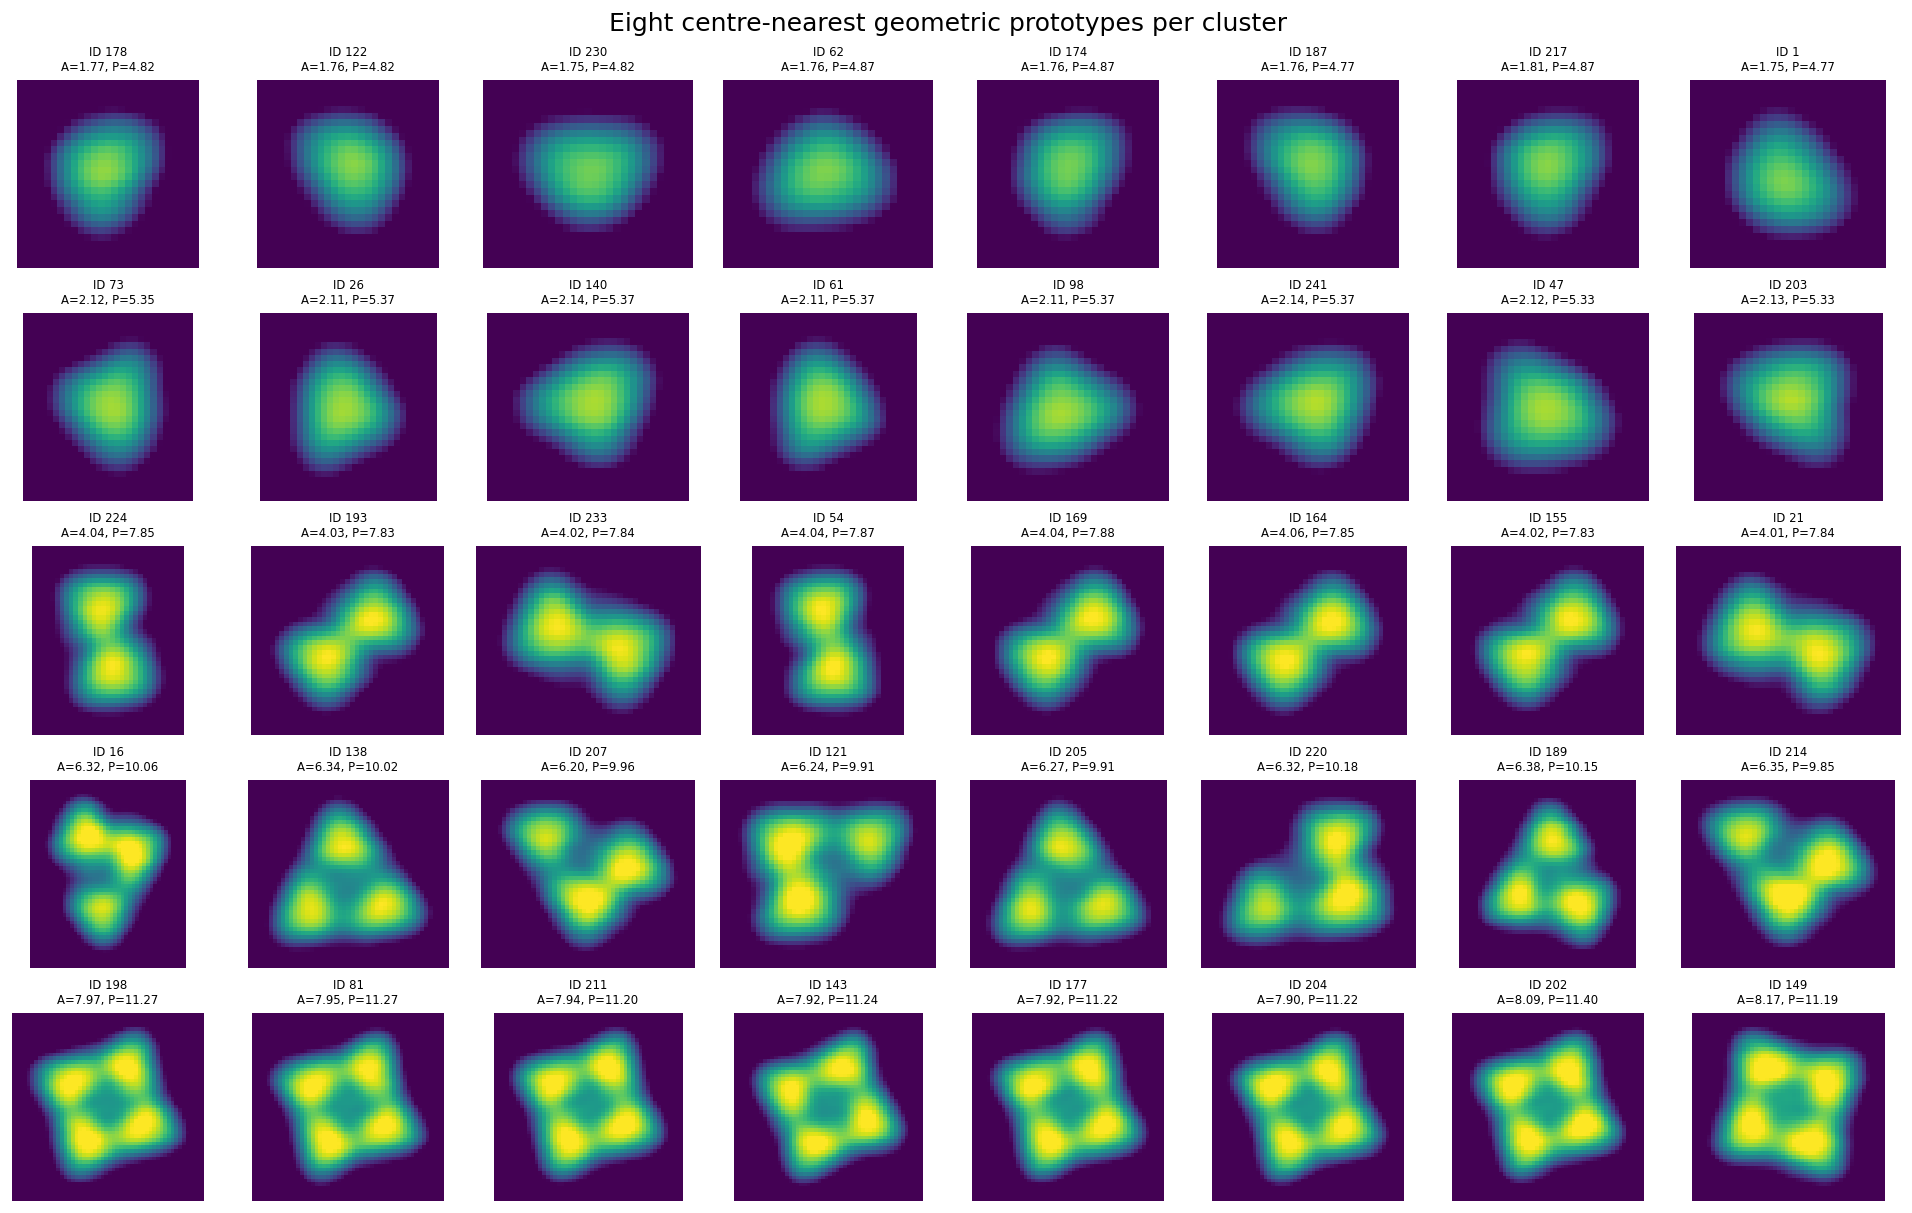

In [17]:
EXAMPLES_PER_CLUSTER = 8
candidate_height_values = corrected_height[label_image > 0]
montage_vmin, montage_vmax = np.percentile(
    candidate_height_values, [2, 98]
)

fig, axes = plt.subplots(
    N_CLUSTERS,
    EXAMPLES_PER_CLUSTER,
    figsize=(16, 10),
    constrained_layout=True,
)

for cluster_index, cluster_id in enumerate(range(1, 6)):
    examples = (
        clustered_table.loc[
            clustered_table["cluster_id"] == cluster_id
        ]
        .nsmallest(EXAMPLES_PER_CLUSTER, "distance_to_cluster_centre")
        .reset_index(drop=True)
    )
    for column_index, ax in enumerate(axes[cluster_index]):
        if column_index >= len(examples):
            ax.set_axis_off()
            continue

        candidate = examples.iloc[column_index]
        pad = 4
        r0 = max(0, int(candidate["min_row"]) - pad)
        c0 = max(0, int(candidate["min_col"]) - pad)
        r1 = min(corrected_height.shape[0], int(candidate["max_row"]) + pad)
        c1 = min(corrected_height.shape[1], int(candidate["max_col"]) + pad)
        crop = corrected_height[r0:r1, c0:c1]

        ax.imshow(
            crop,
            cmap="viridis",
            vmin=montage_vmin,
            vmax=montage_vmax,
            interpolation="nearest",
        )
        ax.set_title(
            f"ID {int(candidate['object_id'])}\n"
            f"A={candidate['area_nm2']:.2f}, "
            f"P={candidate['perimeter_nm']:.2f}",
            fontsize=7,
        )
        ax.set_axis_off()

    axes[cluster_index, 0].set_ylabel(
        f"C{cluster_id}",
        fontsize=12,
        fontweight="bold",
    )

fig.suptitle(
    "Eight centre-nearest geometric prototypes per cluster",
    fontsize=15,
)
cluster_montage_path = (
    CLUSTER_OUTPUT_DIR / "area_perimeter_cluster_montage.png"
)
fig.savefig(cluster_montage_path, dpi=200, bbox_inches="tight")
plt.show()

## 18. Export and independently reload the clustering hand-off

The assignments file retains object IDs, locations, the two input features, cluster labels, centre distances, and silhouette values. The summary and metrics files record the five centres and the internal validation evidence.

No chemical class name is added at this stage. The exported `cluster_id` is an unsupervised geometric group only.

In [18]:
assignment_columns = [
    "source_image",
    "preprocessing_method",
    "object_id",
    "centroid_row",
    "centroid_col",
    "min_row",
    "min_col",
    "max_row",
    "max_col",
    "area_nm2",
    "perimeter_nm",
    "cluster_id",
    "cluster_label",
    "distance_to_cluster_centre",
    "silhouette_value",
]

cluster_assignments_path = (
    CLUSTER_OUTPUT_DIR / "area_perimeter_cluster_assignments.csv"
)
cluster_summary_path = (
    CLUSTER_OUTPUT_DIR / "area_perimeter_cluster_summary.csv"
)
cluster_metrics_path = (
    CLUSTER_OUTPUT_DIR / "area_perimeter_cluster_metrics.csv"
)

clustered_table[assignment_columns].to_csv(
    cluster_assignments_path,
    index=False,
)
cluster_summary.to_csv(cluster_summary_path, index=False)
cluster_metrics.to_csv(cluster_metrics_path, index=False)

reloaded_assignments = pd.read_csv(cluster_assignments_path)
reloaded_summary = pd.read_csv(cluster_summary_path)
reloaded_metrics = pd.read_csv(cluster_metrics_path)

assert len(reloaded_assignments) == len(feature_table)
assert reloaded_assignments["object_id"].is_unique
assert set(reloaded_assignments["cluster_id"]) == set(range(1, 6))
assert reloaded_summary["candidate_count"].sum() == len(feature_table)
assert set(reloaded_metrics["metric"]) == set(cluster_metrics["metric"])

print("Clustering export validation passed.")
print(f"Assignments: {cluster_assignments_path}")
print(f"Cluster summary: {cluster_summary_path}")
print(f"Metrics: {cluster_metrics_path}")
print(f"Scatter figure: {cluster_scatter_path}")
print(f"Silhouette figure: {silhouette_path}")
print(f"STM overlay: {cluster_overlay_path}")
print(f"Prototype montage: {cluster_montage_path}")

Clustering export validation passed.
Assignments: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P2/outputs/alternative_1_features/area_perimeter_kmeans/area_perimeter_cluster_assignments.csv
Cluster summary: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P2/outputs/alternative_1_features/area_perimeter_kmeans/area_perimeter_cluster_summary.csv
Metrics: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P2/outputs/alternative_1_features/area_perimeter_kmeans/area_perimeter_cluster_metrics.csv
Scatter figure: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P2/outputs/alternative_1_features/area_perimeter_kmeans/area_perimeter_kmeans_scatter.png
Silhouette figure: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/

## Interpretation boundary and next validation step

This section answers a limited question: whether Alternative 1 candidates form five stable groups in the two-dimensional area-perimeter space.

It does **not** establish molecular identity. The next step is to match `object_id` or centroid coordinates to the paper's annotated reference, construct a ground-truth class column, and then measure whether each geometric cluster predominantly contains one target molecular class. P2 and P3 should only be named after that comparison.